<a href="https://colab.research.google.com/github/Western-Windows/SociaLift/blob/engagement/engagement_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Preparing Dependancies**

In [1]:
# 0. Install dependencies (Colab / local with internet)
%pip install -q transformers datasets accelerate sentencepiece scikit-learn torch tqdm emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 13.2 MB/s eta 0:00:00


# Imports and configuration and data preparation

In [2]:


import json
import os
import random
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import emoji
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSeq2SeqLM,
    get_linear_schedule_with_warmup
)

tqdm.pandas()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
import pandas as pd
import os
import json
from datetime import datetime

class ExperimentTracker:
    def __init__(self, log_path="experiment_history.csv"):
        self.log_path = log_path

    def log_run(self, model_name, accuracy, f1_macro, experiment_notes="", cm_data=""):
        """Logs the model performance, notes, and the confusion matrix data to a CSV file."""
        new_entry = {
            "Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "Model": model_name,
            "Accuracy": round(accuracy, 4),
            "Macro_F1": round(f1_macro, 4),
            "Notes": experiment_notes,
            "Confusion_Matrix": cm_data  # Now storing the actual numbers
        }

        if os.path.exists(self.log_path):
            df_logs = pd.read_csv(self.log_path)
            df_logs = pd.concat([df_logs, pd.DataFrame([new_entry])], ignore_index=True)
        else:
            df_logs = pd.DataFrame([new_entry])

        df_logs.to_csv(self.log_path, index=False)
        print(f"✅ Logged {model_name} to {self.log_path}")
        return df_logs.tail(5)
from google.colab import drive
drive.mount('/content/drive')

# Update the path to save directly into your Google Drive
tracker = ExperimentTracker(log_path="/content/drive/MyDrive/experiment_history.csv")

Mounted at /content/drive


## Load Brand Data & Build Follower Map

In [4]:
with open('Facebook_Brand_Data1.json', 'r', encoding='utf-8') as f:
    brand_metadata = json.load(f)

def parse_followers(f_str):
    """Convert '~1.9M', '43K', '450' etc. to an integer."""
    if not isinstance(f_str, str):
        return np.nan
    f_str = f_str.replace('~', '').replace(',', '').strip().upper()
    mult = 1
    if 'K' in f_str:   mult = 1_000;           f_str = f_str.replace('K', '')
    elif 'M' in f_str: mult = 1_000_000;        f_str = f_str.replace('M', '')
    elif 'B' in f_str: mult = 1_000_000_000;    f_str = f_str.replace('B', '')
    try:
        return int(float(f_str) * mult)
    except ValueError:
        return np.nan

# Index both Brand Name and Username (lowercased) for maximum coverage
followers_map = {}
for brand in brand_metadata:
    val = parse_followers(brand.get('Followers', ''))
    for key in [brand.get('Brand Name', ''), brand.get('Username', '')]:
        k = str(key).lower().strip()
        if k:
            followers_map[k] = val

## Alias Map

In [5]:
# -------------------------------------------------------------
#    Maps every post page_name variant (lowercased) that doesn't
#    directly match followers_map to the correct key that does.
#
#    Covers:
#    - Numeric-ID pages where scraper returned username as brand name
#    - Arabic subtitle appended to brand name  (Brand - Arabic)
#    - Long descriptions embedded in post page names
#    - Scraper-truncated or differently formatted brand names
# -------------------------------------------------------------
aliases = {
    # Numeric-ID pages
    '2man jeans wear'                                             : '2manjeans2man',
    '400 four hundred_egypt'                                      : '400.egypt',

    # Arabic subtitle variants
    '8west - ٨ غرب'                                               : '8west',
    'cizaro - سيزارو'                                             : 'cizaro',
    'gounela - جونلة'                                             : 'gounela',
    'lis décence - لى ديسونس'                                     : 'lis décence',
    'mlmar - casual wear'                                         : 'mlmar',
    'motion- موشن'                                                : 'motion',
    'sutra - سُترة'                                                 : 'sutra',
    'أبو الفداء - abo el-fedaa'                                   : 'أبو الفداء',

    # Long description in post page name
    'brands club - online brands clothes store from usa in egypt' : 'brandsclubegyptt',
    'creative design - التصميم الإبداعي'                          : 'creative design',
    'fashion retail group - frg'                                  : 'fashion retail group',

    # Display name ≠ scraped brand name
    'canvas wear'                                                 : 'canvas.wear.eg',
    'chertex jeans'                                               : 'chertexfactory',
    'custom clothes egy'                                          : 'custom0clothes0egy',
    'designia mall'                                               : 'malldesignia',
    'je-x'                                                        : 'jeoxstores',
    'mw fashion consultancy'                                      : 'mwfashionconsultancy',
    'shots wear'                                                  : 'shotsweareg',
    'the anime house'                                             : 'theanimeHouse'.lower(),
    'the scoop politics'                                          : 'the scoop',
    'vestiti-eg'                                                  : 'vestiti',

    # Scraper truncated brand name to single letter 'T' for both T-shirt pages
    't-shirt company'                                             : 'tshirtcompanyy',
    't-shirty'                                                    : 'tshirtprinteg',
}

# Sanity-check: all alias targets must exist in followers_map
missing_targets = {k: v for k, v in aliases.items() if v not in followers_map}
if missing_targets:
    print(f"[WARNING] {len(missing_targets)} alias target(s) not found in followers_map:")
    for k, v in missing_targets.items():
        print(f"  {k!r} -> {v!r}")


## Load Posts Data & Flatten

In [6]:
with open('posts_dataset.json', 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

flattened_rows = []
unresolved_pages = set()

for file_key, doc in tqdm(raw_data.items()):
    posts = doc.get('data', [])
    for post in posts:
        row = {}
        owing_profile = post.get('owing_profile', {})

        row['page_name']       = owing_profile.get('name') or owing_profile.get('short_name')
        row['post_text']       = post.get('context')
        row['date_of_publish'] = post.get('published_date')

        # Resolve followers: direct match → alias fallback → NaN
        search_key   = str(row['page_name']).lower().strip()
        resolved_key = aliases.get(search_key, search_key)
        followers_val = followers_map.get(resolved_key, np.nan)
        row['page_followers'] = followers_val

        if pd.isna(followers_val):
            unresolved_pages.add(row['page_name'])

        # Sub-reactions mapped from Arabic labels
        sub_reactions      = post.get('sub_reactions', {}) or {}
        row['like_count']  = sub_reactions.get('أعجبني', 0)
        row['love_count']  = sub_reactions.get('أحببته', 0)
        row['haha_count']  = sub_reactions.get('هاهاها', 0)
        row['wow_count']   = sub_reactions.get('واااو',  0)
        row['sad_count']   = sub_reactions.get('أحزنني', 0)
        row['angry_count'] = sub_reactions.get('أغضبني', 0)
        row['care_count']  = sub_reactions.get('أدعمه',  0)

        row['total_reactions'] = post.get('reaction_count.count', 0)
        row['comments_count']  = post.get('comment_rendering_instance.comments.total_count', 0)
        row['share_count']     = post.get('share_count.count', 0)

        flattened_rows.append(row)

posts_df = pd.DataFrame(flattened_rows)

print(f"\nTotal posts      : {len(posts_df)}")
print(f"Followers matched: {posts_df['page_followers'].notna().sum()}")
print(f"Followers missing: {posts_df['page_followers'].isna().sum()}")
if unresolved_pages:
    print(f"Unresolved pages ({len(unresolved_pages)}) — not present in brand data:")
    for p in sorted(unresolved_pages):
        print(f"  {p!r}")

100%|██████████| 161/161 [00:00<00:00, 3474.75it/s]


Total posts      : 4715
Followers matched: 4668
Followers missing: 47
Unresolved pages (12) — not present in brand data:
  'COMFO WEAR '
  'GLAM Fashion & Styling Agency'
  'Hassan Aboali II'
  'Limited Edition'
  'Maha Hassan'
  'Proud American Patriot'
  'Reem elmazoon'
  'Style casual wear'
  "Sue's Fashion brand"
  'Trendy moda'
  'بكار بلوجر الغلابه'
  'يوستينا صلاح - Youstina salah'


## Calculate Weighted Engagement Score

In [7]:
reaction_weights = {
    'like_count' : 1.0,
    'love_count' : 2.0,
    'haha_count' : 1.5,
    'wow_count'  : 1.5,
    'sad_count'  : 0.5,
    'angry_count': 0.5,
    'care_count' : 1.5,
    'share_count': 3.0,
}

# Ensure all numeric columns are properly typed
numeric_cols = list(reaction_weights.keys()) + ['page_followers', 'total_reactions',
                                                  'comments_count', 'share_count']
for col in numeric_cols:
    if col in posts_df.columns:
        posts_df[col] = pd.to_numeric(posts_df[col], errors='coerce')

posts_df['engagement_weighted'] = sum(
    w * posts_df[col].fillna(0) for col, w in reaction_weights.items()
)

# Engagement rate: weighted engagement normalised by follower count
followers_series = posts_df['page_followers'].replace(0, pd.NA)
posts_df['engagement_rate'] = (
    posts_df['engagement_weighted'] / followers_series
).fillna(0)


### Drop rows with no follower data

In [8]:
initial_count = len(posts_df)

# Filter rows with valid followers and text in a cleaner way
posts_df = (posts_df.query("page_followers > 0 and page_followers.notna()")
    .dropna(subset=['post_text']).reset_index(drop=True).copy())

# Log results with specific counts
dropped_total = initial_count - len(posts_df)
print(f"--- Data Cleaning Summary ---")
print(f"Initial rows: {initial_count}")
print(f"Dropped:      {dropped_total}")
print(f"Remaining:    {len(posts_df)}")


--- Data Cleaning Summary ---
Initial rows: 4715
Dropped:      164
Remaining:    4551


##Label Engagement and saving

In [9]:

# Define engagement labels
# Using 0.67 split to separate 'high' engagement (top 33%) from 'not_high'
posts_df['engagement_label'] = pd.qcut(
    posts_df['engagement_rate'],
    q=[0,0.40, 0.60, 1.0],
    labels=['low','avg', 'high']
)



# Update label count for the model
NUM_LABELS = posts_df['engagement_label'].nunique()

print(f"\nEngagement label distribution:")
print(posts_df['engagement_label'].value_counts())

# Save the cleaned dataset
posts_df.to_csv('final_dataset_with_followers.csv', index=False)
print("\nSaved → final_dataset_with_followers.csv")


Engagement label distribution:
engagement_label
low     1823
high    1820
avg      908
Name: count, dtype: int64

Saved → final_dataset_with_followers.csv


# EDA Analysis

/tmp/ipykernel_715/3453575886.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=posts_df, x='engagement_label', order=['low', 'avg', 'high'], palette='viridis')
/tmp/ipykernel_715/3453575886.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_pages.index, x=top_pages.values, palette='Blues_r')
/tmp/ipykernel_715/3453575886.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_eng_pages.index, x=top_eng_pages.values, palette='Oranges_r')
/tmp/ipykernel_715/3453575886.py:58: FutureWarning: 'M' is deprecated and will be re

Plots generated successfully.
153 unique pages.
4551 total posts.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


  page_name                                          post_text  \
0   Damagon  مرحبًا بكم في [Damagon]!\n\nنقدم لكم تجربة فري...   
1   Trifex   Women’s Extreme Wide-Leg Jeans \nBold, relaxed...   
2   Trifex   Mafeesh Fayda Tee \nHeritage × Streetwear.\nOv...   
3   Trifex   Clean, minimal, and made for everyday comfort....   
4   shxo.eg  Comfort meets attitude — SHXO sweats.\n\n#shxo...   

      date_of_publish  page_followers  like_count  love_count  haha_count  \
0 2024-09-18 19:33:50           180.0           3           1           0   
1 2025-11-25 00:10:37            70.0           0           0           0   
2 2025-11-24 23:46:28            70.0           0           0           0   
3 2025-11-23 23:36:18            70.0           0           0           0   
4 2026-02-09 16:29:12           165.0           6           2           0   

   wow_count  sad_count  angry_count  care_count  total_reactions  \
0          0          0            0           0                4   
1 

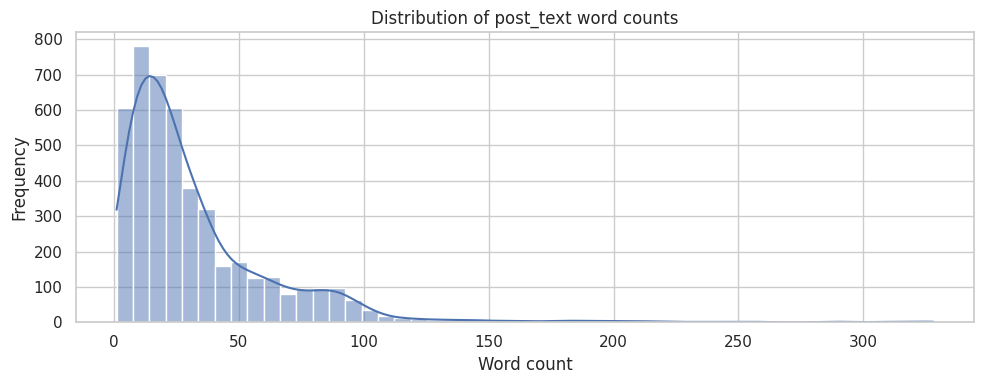

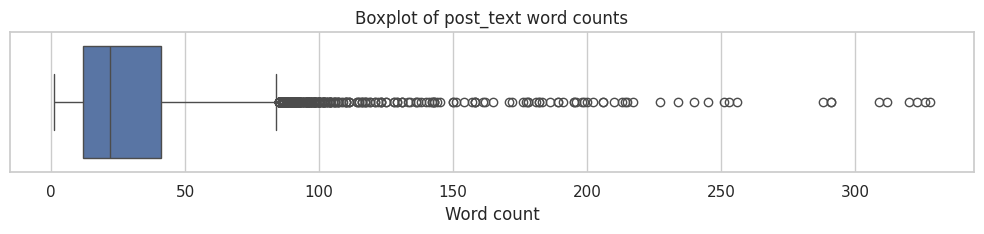

In [10]:
#gemini eda

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import nltk
from nltk.corpus import stopwords

# Ensure date is datetime
posts_df['date_of_publish'] = pd.to_datetime(posts_df['date_of_publish'], errors='coerce')

# Set aesthetic style
sns.set_theme(style="whitegrid")

# 1. Distribution of Engagement Label
plt.figure(figsize=(8, 5))
sns.countplot(data=posts_df, x='engagement_label', order=['low', 'avg', 'high'], palette='viridis')
plt.title('Distribution of Engagement Labels')
plt.xlabel('Engagement Label')
plt.ylabel('Count')
plt.savefig('engagement_label_dist.png', bbox_inches='tight')
plt.close()

# 2. Top 10 Pages by Number of Posts
plt.figure(figsize=(10, 6))
top_pages = posts_df['page_name'].value_counts().nlargest(10)
sns.barplot(y=top_pages.index, x=top_pages.values, palette='Blues_r')
plt.title('Top 10 Pages by Number of Posts')
plt.xlabel('Number of Posts')
plt.ylabel('Page Name')
plt.savefig('top_pages_posts.png', bbox_inches='tight')
plt.close()

# 3. Average Engagement Rate by Top 10 Pages
plt.figure(figsize=(10, 6))
top_eng_pages = posts_df.groupby('page_name')['engagement_rate'].mean().nlargest(10)
sns.barplot(y=top_eng_pages.index, x=top_eng_pages.values, palette='Oranges_r')
plt.title('Top 10 Pages by Average Engagement Rate')
plt.xlabel('Average Engagement Rate')
plt.ylabel('Page Name')
plt.savefig('top_eng_pages.png', bbox_inches='tight')
plt.close()

# 4. Correlation Matrix of Metrics
plt.figure(figsize=(10, 8))
corr_cols = ['page_followers', 'like_count', 'love_count', 'haha_count', 'wow_count',
             'sad_count', 'angry_count', 'care_count', 'total_reactions',
             'comments_count', 'share_count', 'engagement_weighted', 'engagement_rate']
corr = posts_df[corr_cols].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Engagement Metrics')
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.close()

# 5. Time Series of Posts over Time
plt.figure(figsize=(12, 5))
posts_df.set_index('date_of_publish').resample('M').size().plot(color='teal', linewidth=2)
plt.title('Number of Posts Over Time (Monthly)')
plt.xlabel('Date of Publish')
plt.ylabel('Post Count')
plt.grid(True)
plt.savefig('posts_over_time.png', bbox_inches='tight')
plt.close()

# Summary statistics for text response
summary_stats = posts_df.describe().to_dict()
missing_values = posts_df.isnull().sum().to_dict()

print("Plots generated successfully.")
print(posts_df['page_name'].nunique(), "unique pages.")
print(posts_df.shape[0], "total posts.")


# Make plots look a bit nicer
sns.set(style="whitegrid")

# 2. Ensure NLTK resources are available
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')
    nltk.download('punkt')
    nltk.download('wordnet')

# Quick look at the data
print(posts_df.head())

# 4. Basic text EDA on post_text
posts_df['post_text'] = posts_df['post_text'].astype(str)

# Length features
posts_df['text_length_chars'] = posts_df['post_text'].str.len()
posts_df['text_length_words'] = posts_df['post_text'].str.split().apply(len)

# Summary statistics of lengths
print(posts_df[['text_length_chars', 'text_length_words']].describe())

# Distribution of word counts
plt.figure(figsize=(10, 4))
sns.histplot(posts_df['text_length_words'], bins=50, kde=True)
plt.title('Distribution of post_text word counts')
plt.xlabel('Word count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Boxplot of word counts
plt.figure(figsize=(10, 2.5))
sns.boxplot(x=posts_df['text_length_words'])
plt.title('Boxplot of post_text word counts')
plt.xlabel('Word count')
plt.tight_layout()
plt.show()

# Preprocessing

In [11]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

#TRIAL 2: EMOJI TRANSLATION
# 1. Translate Emojis to text so the model understands them
def emoji_text(text):
    if not isinstance(text, str):
        return ""
    # Convert emojis to descriptive text (e.g., 🔥 -> :fire:)
    return emoji.demojize(text)

def clean_text(text):
    # Lowercase
    text = text.lower()

    # Remove URLs (fixed double backslash)
    text = re.sub(r"http\S+", " ", text)

    # Explicitly remove punctuation using string.punctuation (fastest method)
    # This translates all punctuation characters to None (removes them)
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove any remaining non-alphanumeric characters (keep spaces)
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Normalize whitespace (fixed double backslash)
    text = re.sub(r"\s+", " ", text).strip()

    return text

def preprocess_text(text):
    # emojis = emoji_text(text)
    cleaned = clean_text(text)
    tokens = cleaned.split()
    # # Remove stopwords
    # tokens = [t for t in tokens if t not in stop_words]
    # # Lemmatize
    # tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

# 6. Apply preprocessing with progress bar
tqdm.pandas()
posts_df['post_text_clean'] = posts_df['post_text'].progress_apply(preprocess_text)

# Inspect original vs cleaned
print(posts_df[['post_text', 'post_text_clean']].head())

# 7. Save processed dataset
output_path = 'final_dataset_with_followers_processed.csv'
posts_df.to_csv(output_path, index=False)
print(output_path)

100%|██████████| 4551/4551 [00:00<00:00, 6195.69it/s]


                                           post_text  \
0  مرحبًا بكم في [Damagon]!\n\nنقدم لكم تجربة فري...   
1  Women’s Extreme Wide-Leg Jeans \nBold, relaxed...   
2  Mafeesh Fayda Tee \nHeritage × Streetwear.\nOv...   
3  Clean, minimal, and made for everyday comfort....   
4  Comfort meets attitude — SHXO sweats.\n\n#shxo...   

                                     post_text_clean  
0                                            damagon  
1  women s extreme wideleg jeans bold relaxed and...  
2  mafeesh fayda tee heritage streetwear oversize...  
3  clean minimal and made for everyday comfort he...  
4  comfort meets attitude shxo sweats shxo localb...  
final_dataset_with_followers_processed.csv


# Optional Translation

In [12]:
translate = False  # Set to True if you want to translate, does it translate correctly?

if translate:
    translation_model_name = "Helsinki-NLP/opus-mt-mul-en"
    trans_tokenizer = AutoTokenizer.from_pretrained(translation_model_name)
    trans_model = AutoModelForSeq2SeqLM.from_pretrained(translation_model_name).to(device)

    def translate_batch(texts, max_length=128, batch_size=16):
        out = []
        for i in tqdm(range(0, len(texts), batch_size), desc="Translating"):
            batch = texts[i:i+batch_size]
            enc = trans_tokenizer(
                batch,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=max_length
            ).to(device)
            with torch.no_grad():
                gen = trans_model.generate(**enc, max_length=max_length)
            decoded = trans_tokenizer.batch_decode(gen, skip_special_tokens=True)
            out.extend(decoded)
        return out

    # Using post_text directly if translation is skipped, or creating the translated column
    posts_df["post_text_en"] = translate_batch(posts_df["post_text_clean"].astype(str).tolist())
else:
    # If no translation, we use the original text for the following steps
    posts_df["post_text_en"] = posts_df["post_text_clean"].astype(str)

# Train/validation split and label encoding

In [13]:

# Make runs reproducible (reduces variance and makes tuning meaningful)
import os
import random
import numpy as np
import torch

seed_val = 42

random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)

os.environ["PYTHONHASHSEED"] = str(seed_val)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(seed_val)


label_encoder = LabelEncoder()
posts_df["label_id"] = label_encoder.fit_transform(posts_df["engagement_label"].astype(str))
num_labels = len(label_encoder.classes_)
print("Labels:", list(label_encoder.classes_), "num_labels:", num_labels)

# Stratified split
train_df, val_df = train_test_split(
    posts_df,
    test_size=0.1,
    random_state=seed_val,
    stratify=posts_df["label_id"]
)

print(train_df["label_id"].value_counts(normalize=True).sort_index())
print(val_df["label_id"].value_counts(normalize=True).sort_index())

print("Train size:", len(train_df), "Val size:", len(val_df))

42
Labels: ['avg', 'high', 'low'] num_labels: 3
label_id
0    0.199512
1    0.400000
2    0.400488
Name: proportion, dtype: float64
label_id
0    0.199561
1    0.399123
2    0.401316
Name: proportion, dtype: float64
Train size: 4095 Val size: 456


# **Models**

## 1. TF-IDF + Logistic Regression baseline

TF-IDF + LR accuracy: 0.6535087719298246
TF-IDF + LR macro F1: 0.6361592663599999
              precision    recall  f1-score   support

         avg       0.39      0.63      0.48        91
        high       0.75      0.69      0.72       182
         low       0.80      0.63      0.70       183

    accuracy                           0.65       456
   macro avg       0.65      0.65      0.64       456
weighted avg       0.70      0.65      0.67       456



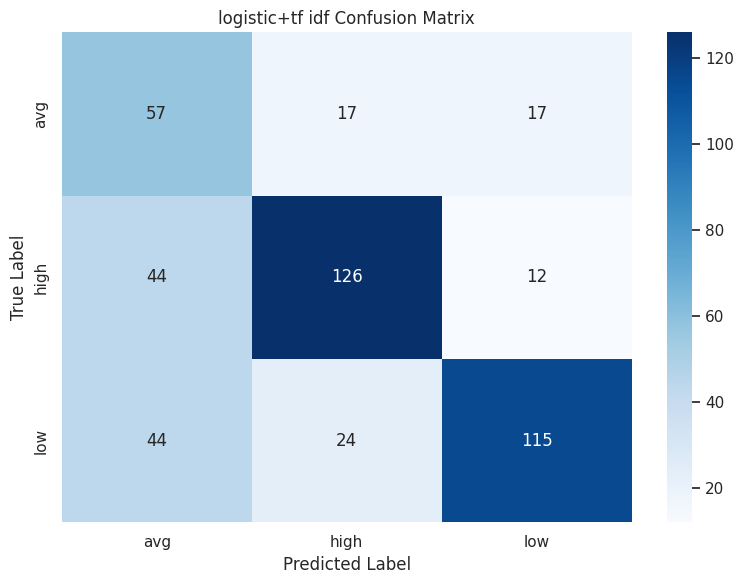

✅ Logged TF-IDF + Logistic Regression to /content/drive/MyDrive/experiment_history.csv


,Timestamp,Model,Accuracy,Macro_F1,Notes,Confusion_Matrix
2,2026-03-20 01:28:47,roberta-base,0.6425,0.5703,"Baseline standard text cleaning, 3 epochs, lr=...","[[21, 23, 47], [14, 125, 43], [11, 25, 147]]"
3,2026-03-20 01:36:42,xlm-roberta-base,0.6623,0.5666,"Baseline standard text cleaning, 3 epochs, lr=...","[[15, 32, 44], [6, 146, 30], [7, 35, 141]]"
4,2026-03-20 01:38:53,microsoft/deberta-v3-base,0.3991,0.1902,"DeBERTa specific settings: lr=1e-5, eps=1e-6, ...","[[0, 91, 0], [0, 182, 0], [0, 183, 0]]"
5,2026-03-20 01:47:31,answerdotai/ModernBERT-base,0.6491,0.5884,"Baseline standard text cleaning, 3 epochs, lr=...","[[26, 21, 44], [17, 127, 38], [16, 24, 143]]"
6,2026-03-20 17:47:33,TF-IDF + Logistic Regression,0.6535,0.6362,"Baseline, max_features=20k","[[57, 17, 17], [44, 126, 12], [44, 24, 115]]"


In [14]:


tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=3
)

X_train_tfidf = tfidf.fit_transform(train_df["post_text_en"])
X_val_tfidf = tfidf.transform(val_df["post_text_en"])

log_reg = LogisticRegression(
    max_iter=200,
    n_jobs=-1,
    class_weight="balanced"
)
log_reg.fit(X_train_tfidf, train_df["label_id"])

val_pred_lr = log_reg.predict(X_val_tfidf)
val_pred_lr_proba = log_reg.predict_proba(X_val_tfidf)

print("TF-IDF + LR accuracy:", accuracy_score(val_df["label_id"], val_pred_lr))
print("TF-IDF + LR macro F1:", f1_score(val_df["label_id"], val_pred_lr, average="macro"))
print(classification_report(val_df["label_id"], val_pred_lr, target_names=label_encoder.classes_))
# Calculate the confusion matrix
cm = confusion_matrix(val_df["label_id"], val_pred_lr)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.title('logistic+tf idf Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# 1. Convert the confusion matrix array to a JSON string
cm_string = json.dumps(cm.tolist())

# 2. Calculate metrics
tfidf_lr_acc = accuracy_score(val_df["label_id"], val_pred_lr)
tfidf_lr_f1 = f1_score(val_df["label_id"], val_pred_lr, average="macro")

# 3. Log the baseline WITH the cm_data argument included!
tracker.log_run(
    model_name="TF-IDF + Logistic Regression",
    accuracy=tfidf_lr_acc,
    f1_macro=tfidf_lr_f1,
    experiment_notes="Baseline, max_features=20k",
    cm_data=cm_string  # <-- This saves the matrix numbers into the CSV
)

## Transformer models

In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback

class TransformerDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            texts, truncation=True, padding=True, max_length=max_length, return_tensors="pt"
        )
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro')
    }

def train_and_evaluate_model(model_name, train_df, val_df, num_labels, target_names, experiment_notes="",
                             learning_rate=2e-5, adam_epsilon=1e-8, warmup_ratio=0.0):
    print(f"\n{'='*50}\nTraining {model_name}\n{'='*50}")

    # 1. Initialize Tokenizer and Model
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        ignore_mismatched_sizes=True # Fixes dimension mismatch on classification heads
    )

    # 2. Create Datasets
    train_dataset = TransformerDataset(train_df["post_text_en"].tolist(), train_df["label_id"].tolist(), tokenizer)
    val_dataset = TransformerDataset(val_df["post_text_en"].tolist(), val_df["label_id"].tolist(), tokenizer)

    # 3. Define Training Arguments
    training_args = TrainingArguments(
        output_dir=f"./results_{model_name.replace('/', '_')}",
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        learning_rate=learning_rate,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=500,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        report_to="none", # Disable wandb/wandb logging if not used
        adam_epsilon=adam_epsilon,
        warmup_ratio=warmup_ratio
    )

    # 4. Initialize Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    # 5. Train and Evaluate
    trainer.train()
    eval_results = trainer.evaluate()

    # 6. Generate Predictions for plots
    predictions = trainer.predict(val_dataset)
    preds = np.argmax(predictions.predictions, axis=-1)
    labels = val_df["label_id"].values

    acc = eval_results['eval_accuracy']
    f1 = eval_results['eval_f1_macro']

    # 7. Print Report & Plot Confusion Matrix
    print(f"\n{model_name} Results:")
    print(f"Accuracy: {acc:.4f} | Macro F1: {f1:.4f}")
    print(classification_report(labels, preds, target_names=target_names))

    # Calculate the confusion matrix
    cm = confusion_matrix(labels, preds)

    # Plot it for you to see right now in the notebook
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    # NEW: Convert the numpy array into a string representation to save in the CSV
    cm_string = json.dumps(cm.tolist())

    # 8. Log the results to our tracker
    tracker.log_run(
        model_name=model_name,
        accuracy=acc,
        f1_macro=f1,
        experiment_notes=experiment_notes,
        cm_data=cm_string # Pass the string of numbers here!
    )

    return trainer, predictions.predictions


Training bert-base-uncased


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


bert-base-uncased Results:
Accuracy: 0.6601 | Macro F1: 0.6117
              precision    recall  f1-score   support

         avg       0.43      0.36      0.40        91
        high       0.78      0.68      0.73       182
         low       0.65      0.79      0.71       183

    accuracy                           0.66       456
   macro avg       0.62      0.61      0.61       456
weighted avg       0.66      0.66      0.66       456



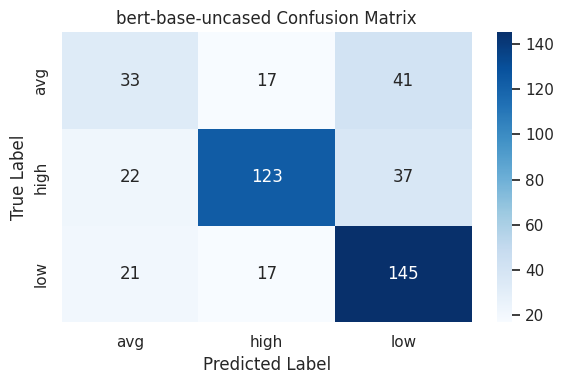

✅ Logged bert-base-uncased to /content/drive/MyDrive/experiment_history.csv

Training roberta-base


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


roberta-base Results:
Accuracy: 0.6645 | Macro F1: 0.6181
              precision    recall  f1-score   support

         avg       0.42      0.38      0.40        91
        high       0.80      0.66      0.73       182
         low       0.67      0.80      0.73       183

    accuracy                           0.66       456
   macro avg       0.63      0.62      0.62       456
weighted avg       0.67      0.66      0.66       456



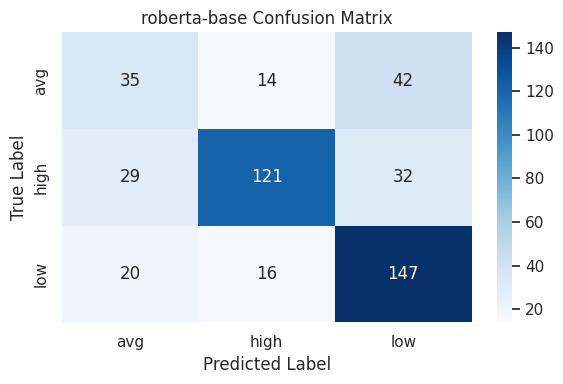

✅ Logged roberta-base to /content/drive/MyDrive/experiment_history.csv

Training xlm-roberta-base


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye


xlm-roberta-base Results:
Accuracy: 0.6645 | Macro F1: 0.6297
              precision    recall  f1-score   support

         avg       0.43      0.47      0.45        91
        high       0.72      0.79      0.75       182
         low       0.74      0.64      0.69       183

    accuracy                           0.66       456
   macro avg       0.63      0.63      0.63       456
weighted avg       0.67      0.66      0.67       456



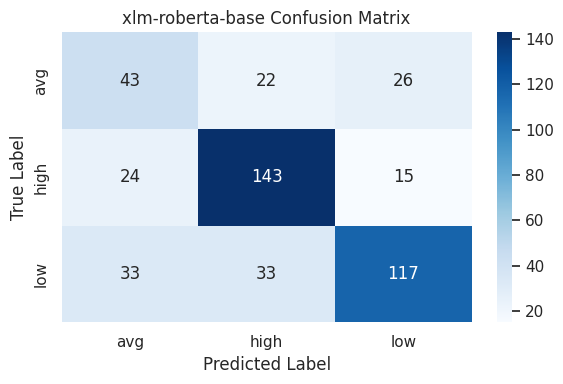

✅ Logged xlm-roberta-base to /content/drive/MyDrive/experiment_history.csv

Training microsoft/deberta-v3-base


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye


microsoft/deberta-v3-base Results:
Accuracy: 0.4912 | Macro F1: 0.3590
              precision    recall  f1-score   support

         avg       0.00      0.00      0.00        91
        high       0.46      0.77      0.58       182
         low       0.55      0.46      0.50       183

    accuracy                           0.49       456
   macro avg       0.34      0.41      0.36       456
weighted avg       0.40      0.49      0.43       456



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


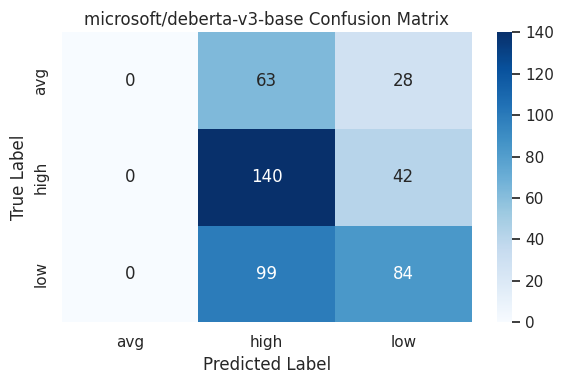

✅ Logged microsoft/deberta-v3-base to /content/drive/MyDrive/experiment_history.csv

Training answerdotai/ModernBERT-base


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,0.810386,0.622807,0.522776
2,0.841685,0.842149,0.629386,0.583873
3,0.841685,0.857222,0.622807,0.556326


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


answerdotai/ModernBERT-base Results:
Accuracy: 0.6294 | Macro F1: 0.5839
              precision    recall  f1-score   support

         avg       0.42      0.35      0.38        91
        high       0.68      0.73      0.70       182
         low       0.66      0.67      0.67       183

    accuracy                           0.63       456
   macro avg       0.59      0.58      0.58       456
weighted avg       0.62      0.63      0.62       456



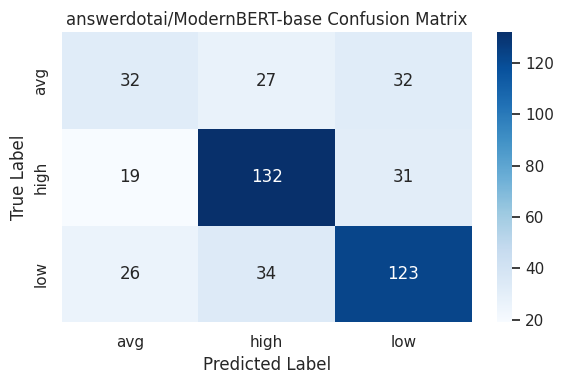

✅ Logged answerdotai/ModernBERT-base to /content/drive/MyDrive/experiment_history.csv


In [16]:
# Make sure you run %pip install sentencepiece before using DeBERTa/XLM
import gc
target_names = list(label_encoder.classes_)
experiment_notes = "Baseline standard text cleaning, 500 epochs, lr=2e-5"

# # 1. BERT
bert_trainer, bert_probs = train_and_evaluate_model(
    "bert-base-uncased", train_df, val_df, num_labels, target_names, experiment_notes
)

# FREE GPU MEMORY
del bert_trainer
gc.collect()
torch.cuda.empty_cache()

# # 2. RoBERTa
roberta_trainer, roberta_probs = train_and_evaluate_model(
    "roberta-base", train_df, val_df, num_labels, target_names, experiment_notes
)

# FREE GPU MEMORY
del roberta_trainer
gc.collect()
torch.cuda.empty_cache()


# # 3. XLM-RoBERTa
xlm_trainer, xlm_probs = train_and_evaluate_model(
    "xlm-roberta-base", train_df, val_df, num_labels, target_names, experiment_notes
)

# FREE GPU MEMORY
del xlm_trainer
gc.collect()
torch.cuda.empty_cache()

# 4. DeBERTa-v3 (Isolated Cell)
deberta_notes = "DeBERTa specific settings: lr=1e-5, eps=1e-6, warmup=0.1"

deberta_trainer, deberta_probs = train_and_evaluate_model(
    "microsoft/deberta-v3-base",
    train_df,
    val_df,
    num_labels,
    target_names,
    experiment_notes=deberta_notes,
    # OVERRIDING THE DEFAULTS:
    learning_rate=1e-5,
    adam_epsilon=1e-6,
    warmup_ratio=0.1
)

# 5. ModernBERT
modern_trainer, modern_probs = train_and_evaluate_model(
    "answerdotai/ModernBERT-base", train_df, val_df, num_labels, target_names, experiment_notes
)